In [16]:
import pathlib
from typing import Tuple
from PIL import Image
import torch 

class Food100L(torch.utils.data.Dataset):
    def  __init__(self
                  ,target_dir:str
                  ,transform=None):
        super().__init__()
        self.paths = list(pathlib.Path(target_dir+"/data").glob("*.png"))
        self.gt_paths = list(pathlib.Path(target_dir+"/gt").glob("*.png"))
        print(self.gt_paths)
        self.transform = transform
        
    def load_image(self,index:int) -> Image.Image:
        image_path = self.paths[index]
        return  Image.open(image_path)
    
    def load_image1(self,path:pathlib.Path) -> Image.Image:
        return  Image.open(path)
    
    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index)  -> Tuple[torch.Tensor,torch.Tensor]:
        image= self.load_image(index)
        label=self.load_image1(self.gt_paths[index])
        return self.transform(image) if self.transform else image,self.transform(label) if self.transform else label
    
    

In [35]:

from torchvision import transforms 


simple_transform = transforms.Compose([
    transforms.ToTensor()
])

d = Food100L("data/test_a",simple_transform)
d

[WindowsPath('data/test_a/gt/0_clean.png'), WindowsPath('data/test_a/gt/10_clean.png'), WindowsPath('data/test_a/gt/11_clean.png'), WindowsPath('data/test_a/gt/12_clean.png'), WindowsPath('data/test_a/gt/13_clean.png'), WindowsPath('data/test_a/gt/14_clean.png'), WindowsPath('data/test_a/gt/15_clean.png'), WindowsPath('data/test_a/gt/16_clean.png'), WindowsPath('data/test_a/gt/17_clean.png'), WindowsPath('data/test_a/gt/18_clean.png'), WindowsPath('data/test_a/gt/19_clean.png'), WindowsPath('data/test_a/gt/1_clean.png'), WindowsPath('data/test_a/gt/20_clean.png'), WindowsPath('data/test_a/gt/21_clean.png'), WindowsPath('data/test_a/gt/22_clean.png'), WindowsPath('data/test_a/gt/23_clean.png'), WindowsPath('data/test_a/gt/24_clean.png'), WindowsPath('data/test_a/gt/25_clean.png'), WindowsPath('data/test_a/gt/26_clean.png'), WindowsPath('data/test_a/gt/27_clean.png'), WindowsPath('data/test_a/gt/28_clean.png'), WindowsPath('data/test_a/gt/29_clean.png'), WindowsPath('data/test_a/gt/2_cle

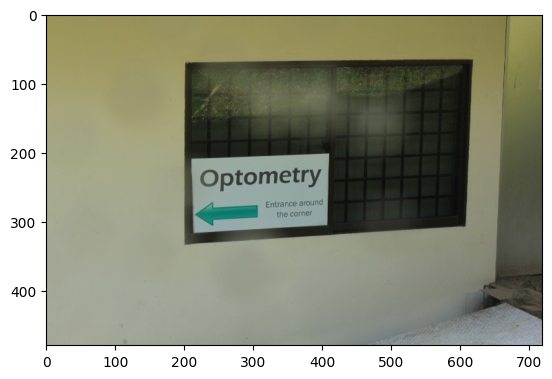

In [39]:
import matplotlib.pyplot as plt
plt.imshow(d[1][0].permute(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20000002..0.34117648].


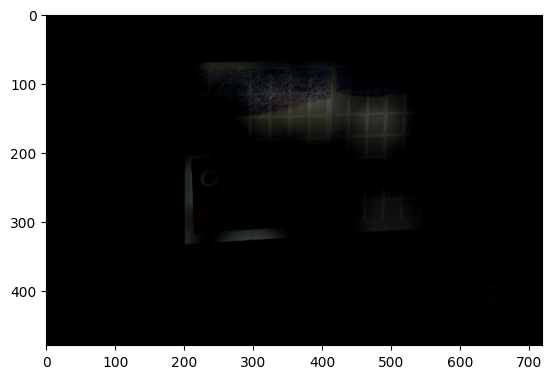

In [40]:
plt.imshow(((d[1][0]) -(d[1][1])).permute(1, 2, 0))